# Nome: Gabriel Delgado Panovich de Barros

# RA: 176313

# Sobre o dataset
---
> Este arquivo foi copiado diretamente da [fonte](https://www.kaggle.com/datasets/vishalsubbiah/pokemon-images-and-types) dos dados, com exceção das imagens.

## Context

Images of all Pokemon from generation 1 to generation 7, along with their types (primary and secondary) as a csv.

## Inspiration

New evolution forms from two different Pokemon. (Create new Pokemon)

Predict Pokemon primary and secondary types from the images. Identify what types the evolution form will have based on the pre-evolved forms. Eg. from Pichu and Pikachu predict for Raichu.

## Future work/Ideas:

Merge with other information such as moves, generation, strong/weak against etc, and use the images to classify.

## Acknowledgements

data scrapped from https://pokemondb.net/pokedex/national

cover image from https://www.hjackets.com/blog/pikachu-costume-for-kids-and-adult/

# Objetivo do projeto
---
Este projeto visa predizer o tipo de um Pokémon baseando-se apenas em sua imagem através de uma rede convolucional simples. Para isso, foram analisadas 5 topologias distintas, a fim de encontrar o modelo que mais se adapte à situação apresentada, e 1 rede MLP para comparação de eficiência.

---

# Importações

In [34]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import Dict, List, Tuple

# Preparação dos dados

In [35]:
class CustomDB(Dataset):
    def __init__(
            self,
            df: pd.DataFrame,
            labels_dict: Dict[int, str],
            img_dir: str,
            transform: callable = None
    ):
        """
        Args:
            df: DataFrame contendo nomes e tipos.
            img_dir: Caminho para a pasta das imagens.
            label_map: Dicionário mapeando {'Tipo': Inteiro}. Garante consistência.
            transform: Transformações do PyTorch.
        """
        # --- Dados do DataFrame ---
        self.full_df = df.reset_index(drop=True) # Garante que os índices sejam 0, 1, 2...
        self.labels_dic = labels_dict # dicionário que associa os tipos a um valor numérico
        # --- Diretório das imagens ---
        self.img_dir = img_dir
        # --- Transformação ---
        self.transform = transform

    def __len__(self):
        return len(self.full_df.index)
    
    def __getitem__(self, index):
        """
        Método que busca um índice no dataset e retorna a imagem acompanhada do seu
        label, em ordem.
        """
        row = self.full_df.iloc[index]
        pk_name = row["Name"] # nome do pokemon
        pk_type = row["Type1"] # tipo do pokemon

        # --- 1. Encontramos o caminho para a imagem relativa ao pokemon do índice ---
        img_path = os.path.join(self.img_dir, f"{pk_name}.png")

        # --- 2. Carregamento e tratamento da imagem ---
        try:
            image = Image.open(img_path)
            # Como as imagens do dataset são no formato .png, sem fundo, adicionamos um fundo.
            if image.mode == "RGBA": # fundo transparente
                background = Image.new("RGB", image.size, (255, 255, 255))
                background.paste(image, mask=image.split()[3]) # 3 é o canal alpha
                image = background
            else:
                image = image.convert("RGB")
        except FileNotFoundError:
            print(f"Aviso: Imagem não encontrada {img_path}.")

        # --- 3. Extraímos o tipo do pokemon ---
        numerical_type = self.labels_dic[pk_type]

        # --- 4. Aplica a transformação na imagem ---
        if self.transform:
            image = self.transform(image)

        return image, int(numerical_type)
    
def prepareData(
        labels_path: str,
        images_path: str,
        batch_size: int = 64
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Carrega os dados em formato de um DataLoader.

    Args:
        labels_path: Caminho para o arquivo .csv que contém os rótulos.
        images_path: Diretório que armazena as imagens.
        batch_size: Tamanho dos lotes de treinamento.

    Output:
        Dados separados conforme a proporção definida internamente em conjuntos de treino,
        validação e teste
    """
    proportions = (0.7, 0.3) # proporções de divisão dos conjuntos (treino, (validação e teste))
    # --- 1. Carregamento do DataFrame e definição de elementos essenciais ---
    full_df = pd.read_csv(labels_path)
    df = filterData(full_df)
    # Dicionário de tipos de pokemons
    labels_df = sorted(df["Type1"].unique())
    #print(labels_df)
    types_dict = {pk_type: i for i, pk_type in enumerate(labels_df)}

    # --- 2. Separação dos conjuntos de treino, validação e teste ---
    # Conjunto de treino
    train_df, temp = train_test_split(
        df,
        test_size=proportions[1],
        stratify=df["Type1"],
        random_state=42
    )
    # Conjuntos de validação e teste
    val_df, test_df = train_test_split(
        temp,
        test_size=0.5,
        stratify=temp["Type1"],
        random_state=42
    )

    # --- 3. Definição das transformações
    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        #transforms.RandomHorizontalFlip(p=0.5), # Espelha a imagem aleatoriamente
        #transforms.RandomRotation(degrees=15, fill=255), # Rotaciona a imagem aleatoriamente
        transforms.ToTensor(),
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])

    # --- 4. Instanciação dos datasets e criação dos dataloaders ---
    train_ds = CustomDB(train_df, types_dict, images_path, train_transform)
    val_ds = CustomDB(val_df, types_dict, images_path, val_test_transform)
    test_ds = CustomDB(test_df, types_dict, images_path, val_test_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0 # colocar em 2 no Colab, caso identifique algum erro
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_loader, val_loader, test_loader

def filterData(
        full_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Remove dados que estejam causando problemas para a peparação dos dataloaders.
    Como há um tipo de pokemon com apenas 3 exemplos, vamos removê-lo para permitir
    que a função train_test_split seja executada corretamente, além de outros tipos
    que possam estar dificultando esse processo.

    Args:
        full_df: DataFrame original, que será alterado.
    Output:
        Retornamos o DataFrame filtrado dos dados problemáticos.
    """
    # --- 1. Conta quantas imagens existem por tipo ---
    counts = full_df['Type1'].value_counts()

    # --- 2. Define um limite mínimo (Ex: 20 imagens) ----
    MIN_SAMPLES = 20
    valid_types = counts[counts >= MIN_SAMPLES].index
    #print(valid_types)

    # --- 3. Filtra o DataFrame mantendo apenas os tipos válidos ---
    return full_df[full_df['Type1'].isin(valid_types)].copy()

# Funções de plotagem de métricas para avaliação do modelo

In [36]:
def plotLosses(loss1: Dict[int, float], loss2: Dict[int ,float], loss1_label: str, loss2_label: str) -> None:
    plt.close("all")
    plt.figure()
    plt.plot(loss1.keys(), loss1.values(), label=loss1_label)
    plt.plot(loss2.keys(), loss2.values(), label=loss2_label)
    plt.title(f"{loss1_label} e {loss2_label}")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.legend()
    plt.show()

def plotCMatrix(labels: np.ndarray, predicted: np.ndarray, class_names: List[str], saving: str):
    # --- 1. Cálculo da Matriz ---
    cm = confusion_matrix(labels, predicted)
    num_classes = cm.shape[0]

    # --- 2. Plotagem ---
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão")
    plt.colorbar()
    
    # Define os labels dos eixos com os nomes reais (ex: Fire, Water)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right") # Rotação ajuda a ler
    plt.yticks(tick_marks, class_names)
    
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Verdadeira")

    # Escrever os valores em cada célula
    thresh = cm.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], "d"),
                horizontalalignment="center",
                verticalalignment="center", # Centraliza verticalmente também
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout() 
    plt.savefig(saving)
    plt.show()

# Funções de treinamento, validação e teste
---
Como foram usadas dois tipos de redes distintas (CNN e MLP), as funções foram desenvolvidas da forma mais genérica possível, garantindo uso por ambas as redes.

In [37]:
def trainModel(
        model: nn.Module,
        train_loader: DataLoader,
        loss_function: callable,
        optimizer,
        device: str
):
    """
    Função de treinamento do modelo, percorrendo uma época.

    Args:
        model: Modelo de rede neural a ser treinado.
        train_loader: DataLoader de treinamento.
        loss_function: Função de erro definida pelo usuário.
        optimizer: Método de cálculo da retropropagação.
        device: Dispositivo de aceleração utilizado.
    Output:
        avg_loss: Média do erro calculado nas iterações da época.
    """
    model.train()
    total_loss = 0.0

    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device) # Labels já são int (long) do Dataset

        optimizer.zero_grad()
        
        # Feedforward
        outputs = model(features) 
        
        # Cálculo do Erro (CrossEntropyLoss aceita Logits e Indices de Classe)
        loss = loss_function(outputs, labels)
        
        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def validateModel(
        model: nn.Module, 
        val_loader: DataLoader, 
        loss_function: callable, 
        device: str
):
    """
    Função de validação do modelo, percorrendo uma época. Como não estamos treinando o modelo, não precisamos
    calcular o gradiente descendente estocástico, o qual é necessário para atualizar os pesos sinápticos dos
    neurônios das camadas ocultas.

    Args:
        model: Modelo de rede neural a ser treinado.
        val_loader: DataLoader de validação.
        loss_function: Função de erro definida pelo usuário.
        device: Dispositivo de aceleração utilizado.
    Output:
        avg_loss: Média do erro calculado nas iterações da época.
    """
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = loss_function(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(val_loader)

def testModel(
        model: nn.Module, 
        test_loader: DataLoader, 
        device: str
):
    """
    Função de teste do modelo.

    Args:
        model: Modelo de rede neural a ser treinado.
        test_loader: DataLoader de testew.
        device: Dispositivo de aceleração utilizado.
    Output:
        accuracy: Acurácia média do modelo.
        real_lst: Lista contendo os labels de cada amostra.
        predicted_lst: Lista contendo o label predito pelo modelo por amostra.
    """
    model.eval()
    correct_cases = 0
    total_samples = 0

    real_lst = []
    predicted_lst = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)

            _, predicted = torch.max(outputs.data, 1)
            
            total_samples += labels.size(0)
            correct_cases += (predicted == labels).sum().item()

            real_lst.extend(labels.cpu().numpy())
            predicted_lst.extend(predicted.cpu().numpy())
    
    return 100 * correct_cases / total_samples, real_lst, predicted_lst

# Classe CNN generalizada

In [38]:
class SimpleCNN(nn.Module):
    def __init__(self, lista_filtros, num_classes):
        super(SimpleCNN, self).__init__()
        layers = []
        in_channels = 3
        
        for num_filtros in lista_filtros:
            # num_filtros: quantidade de neurônios no canal 
            # kernel: janela deslizante
            # padding: estouro do mapa 2D em uma unidade para fora
            layers.append(nn.Conv2d(in_channels, num_filtros, kernel_size=3, padding=1))
            # Batch Norm ajuda a rede a não "viciar" em uma classe
            layers.append(nn.BatchNorm2d(num_filtros))
            layers.append(nn.ReLU()) # escolhido segundo o modelo da AlexNet
            # stride: deslocamento da janela
            layers.append(nn.MaxPool2d(kernel_size=2, stride=1)) # aplica pooling de 2x2 (assim como nos slides da aula 18)
            in_channels = num_filtros # atualiza o tamanho da próxima entrada

        self.feature_extractor = nn.Sequential(*layers) # sequência de camadas convolucionais
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # global pooling  
        self.classifier = nn.Sequential( # classificador mais robusto
            nn.Flatten(),
            # Camada Oculta Densa: Aumentamos a capacidade de raciocínio
            nn.Linear(in_channels, 512), 
            nn.ReLU(),
            nn.Dropout(0.5),             
            # Camada de Saída
            nn.Linear(512, num_classes)   
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

# Classe MLP

In [39]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        """
        Args:
            input_size (int): Total de pixels da imagem (C * H * W). Ex: 3*64*64 = 12288.
            hidden_sizes (list): Lista com o número de neurônios em cada camada oculta.
                                 Ex: [512, 256] cria duas camadas ocultas.
            output_size (int): Número de classes para classificação (Ex: 16 tipos de Pokémon).
        """
        super(MLP, self).__init__()
        # Lista para armazenar as camadas sequencialmente
        layers = []
        last_size = input_size

        # --- Construção Dinâmica das Camadas Ocultas ---
        for hidden_dim in hidden_sizes:
            # --- 1. Camada Linear (v = Σ(wx) + b) ---
            layers.append(nn.Linear(last_size, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            # --- 2. Função de Ativação Não-Linear (v = max(0,x)) ---
            layers.append(nn.ReLU())
            # --- 3. Dropout (Opcional, mas recomendado para evitar overfitting) ---
            layers.append(nn.Dropout(0.5))
            # Atualiza o tamanho de entrada da próxima camada
            last_size = hidden_dim

        # --- Camada de Saída ---
        # Conecta a última camada oculta ao número de classes (Tipos de Pokémon)
        layers.append(nn.Linear(last_size, output_size))
        
        # Empacota tudo em um container Sequencial
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # --- 1. Flattening (Achatar a imagem) ---
        # Transforma o Tensor de imagem (Batch, 3, 64, 64) -> Vetor (Batch, 12288)
        # Sem isso, a camada Linear não aceita a imagem
        x = x.view(x.size(0), -1) 
        
        # --- 2. Passagem pela rede (Linear -> ReLU -> Dropout -> ... -> Saída) ---
        x = self.network(x)
        
        # Não usamos self.sigmoid() ou softmax() aqui no final.
        # O PyTorch (nn.CrossEntropyLoss) prefere receber os "Logits" (valores brutos).
        # Ele aplicará o Softmax internamente de forma mais estável.
        
        return x

# Funções auxiliares
---
Durante o processo de desenvolivmento, foi observado uma acurácia extremamente baixa para a rede convolucional. Estas funções permitiram a visualização de processos internos, que permitiram encontrar possíveis causas para essa acurácia anormal.

### visualize_batch

Permite que visualizemos o conteúdo do dataloader, identificando se há erros no processo de tratamento dos dados.

Inicialmente, foi percebido que as rotações das imagens geravam tarjas pretas nas bordas do da imagem. Por causa disso, a rede recebia dados ruidososw, o que dificultou o processo de treinamento.

Para resolver esse problema, bastou adicionar o parâmetro *fill* na função de transformação aplicada nos dados, em **prepareData**

In [40]:
def visualize_batch(dataloader, classes):
    # Pega um lote de imagens
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(12, 4))
    for idx in range(5):
        ax = plt.subplot(1, 5, idx+1)
        # O PyTorch é (C, H, W), o Matplotlib quer (H, W, C)
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)
        plt.title(classes[labels[idx]])
        plt.axis("off")
    plt.show()

# Modelo 1 - CNN \[16, 32\]
---

Iniciamos com uma topologia bem simples, que aparenta ter sido capaz de aprender o problema. Contudo, tende para um caso de overfitting nas últimas épocas.

Como não obtivemos um resultado satisfatório, precisamos testar outras possibilidades de topologias.

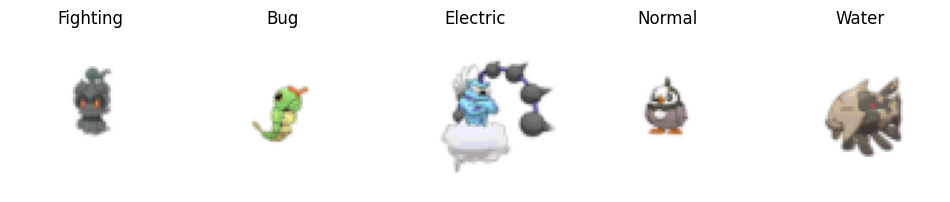

Epoch 5/30 | Train Loss: 2.6943 | Val Loss: 2.6949
Epoch 10/30 | Train Loss: 2.6428 | Val Loss: 2.6495
Epoch 15/30 | Train Loss: 2.6164 | Val Loss: 2.6258
Epoch 20/30 | Train Loss: 2.5694 | Val Loss: 2.5991
Epoch 25/30 | Train Loss: 2.5380 | Val Loss: 2.5780
Epoch 30/30 | Train Loss: 2.5008 | Val Loss: 2.5546


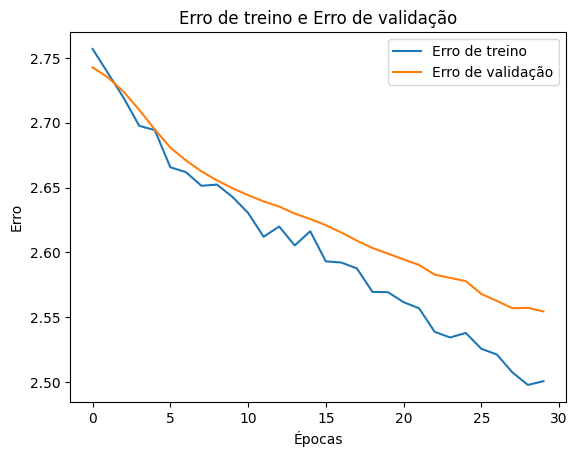


Acurácia final no teste: 25.21%


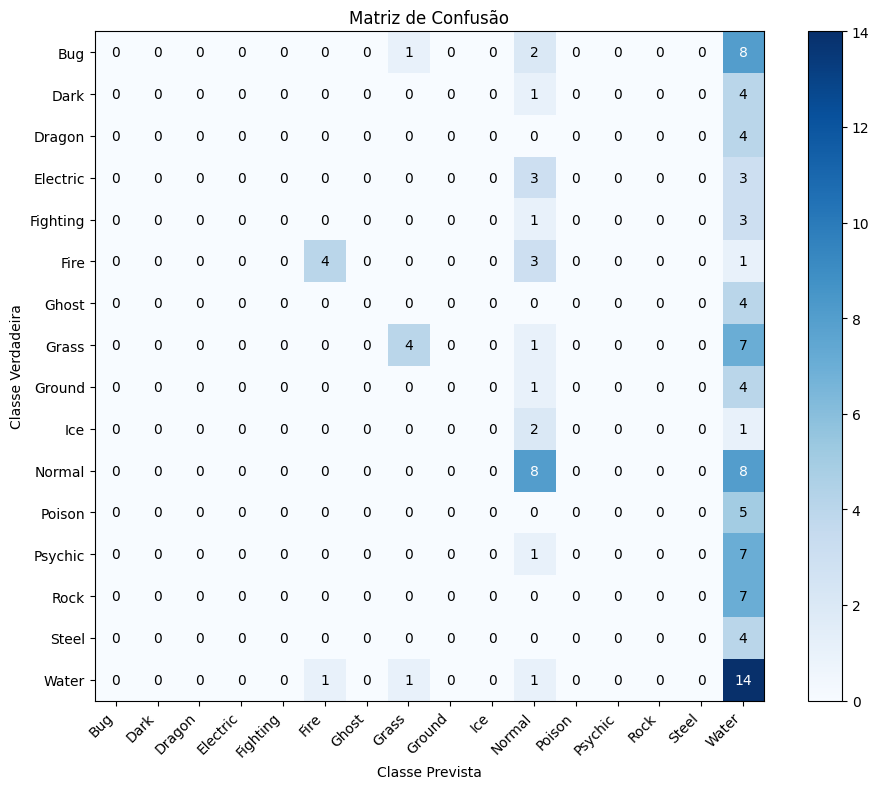

In [41]:
EPOCHS = 30
ETA = 1e-4
INPUT_SIZE = 3 * 64 * 64
FILTERS = [16, 32]
OUTPUT_SIZE = 16
#L2 = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = [
    "Bug", "Dark", "Dragon", "Electric",
    "Fighting", "Fire", "Ghost", "Grass",
    "Ground", "Ice", "Normal", "Poison", 
    "Psychic", "Rock", "Steel", "Water"
]


# Carrega dados do Pokémon
train_loader, val_loader, test_loader = prepareData("db/pokemon.csv", "db/images/")
visualize_batch(train_loader, LABELS)
    
# --- 1. Instancia CNN ---
model = SimpleCNN(lista_filtros=FILTERS, num_classes=OUTPUT_SIZE).to(DEVICE)

# --- 2. Função de Erro correta para Multiclasse ---
loss_function = nn.CrossEntropyLoss() 

# --- 3. Otimizador ---
optimizer = optim.Adam(model.parameters(), lr=ETA)#, weight_decay=L2)

train_loss = {}
val_loss = {}

for i in range(EPOCHS):
    t_loss = trainModel(model, train_loader, loss_function, optimizer, DEVICE)
    v_loss = validateModel(model, val_loader, loss_function, DEVICE)
        
    train_loss[i] = t_loss
    val_loss[i] = v_loss
        
    if (i+1) % 5 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
# Plotagem dos erros
plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação")

# --- 4. Avaliação Final ---
acc, labels, predicted = testModel(model, test_loader, DEVICE)
print(f"\nAcurácia final no teste: {acc:.2f}%")

plotCMatrix(labels, predicted, LABELS, "assets/CNN_ConfusionMatrix1.png")

# Modelo 2 - CNN \[16, 32, 64\]
---

Observamos que o aumento da complexidade levou também ao aumento da precisão, mas ainda longe de um valor satisfatório. Além disso, podemos reparar a tendência do modelo ao overfitting, logo é algo que será mais abordado em modelos posteriores.

Resta aumentar a complexidade do modelo a fim de tentar encontrar uma topologia que melhor se adeque ao problema.

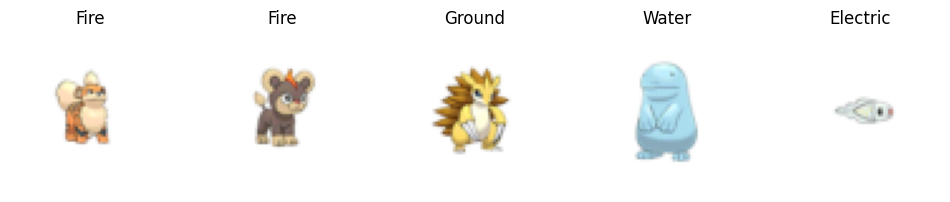

Epoch 5/30 | Train Loss: 2.6640 | Val Loss: 2.6828
Epoch 10/30 | Train Loss: 2.5938 | Val Loss: 2.6186
Epoch 15/30 | Train Loss: 2.5387 | Val Loss: 2.5766
Epoch 20/30 | Train Loss: 2.4918 | Val Loss: 2.5403
Epoch 25/30 | Train Loss: 2.4406 | Val Loss: 2.5021
Epoch 30/30 | Train Loss: 2.3935 | Val Loss: 2.4727


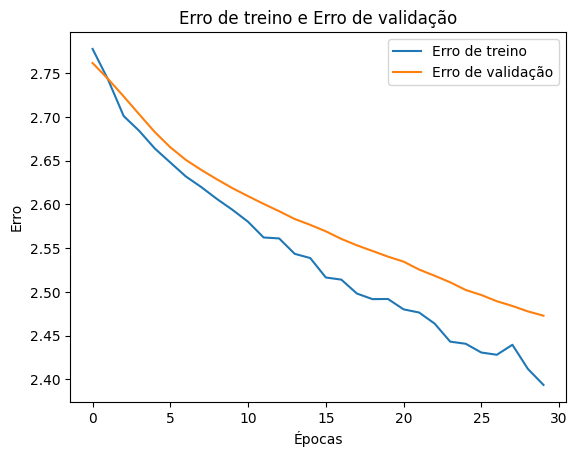


Acurácia final no teste: 29.41%


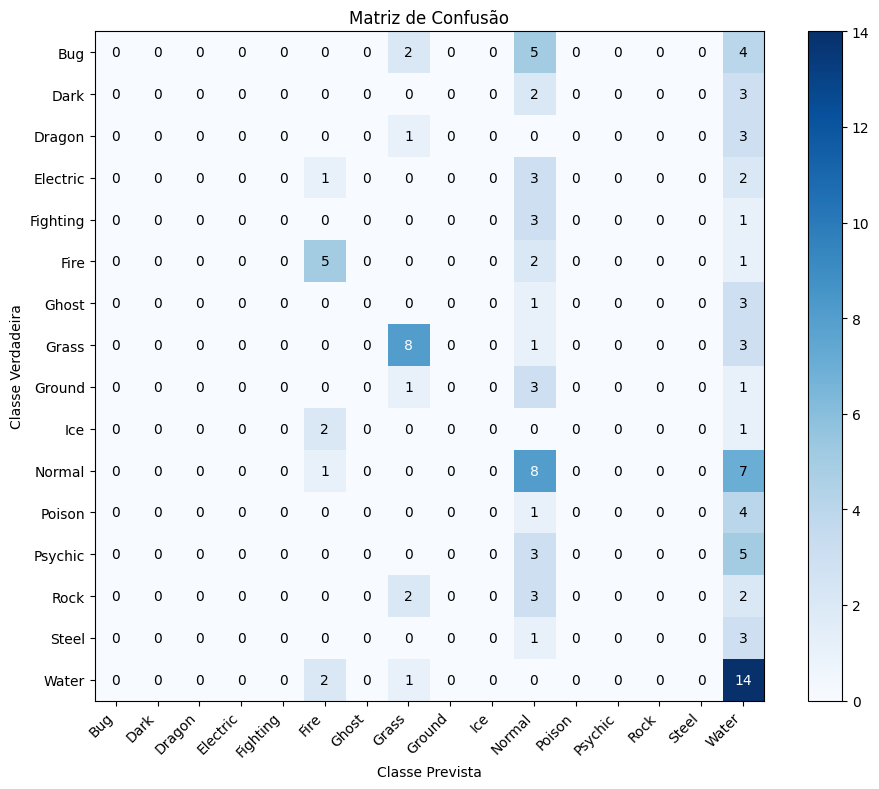

In [42]:
EPOCHS = 30
ETA = 1e-4
INPUT_SIZE = 3 * 64 * 64
FILTERS = [16, 32, 64]
OUTPUT_SIZE = 16
#L2 = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = [
    "Bug", "Dark", "Dragon", "Electric",
    "Fighting", "Fire", "Ghost", "Grass",
    "Ground", "Ice", "Normal", "Poison", 
    "Psychic", "Rock", "Steel", "Water"
]

# Carrega dados do Pokémon
train_loader, val_loader, test_loader = prepareData("db/pokemon.csv", "db/images/")
visualize_batch(train_loader, LABELS)
    
# --- 1. Instancia CNN ---
model = SimpleCNN(lista_filtros=FILTERS, num_classes=OUTPUT_SIZE).to(DEVICE)

# --- 2. Função de Erro correta para Multiclasse ---
loss_function = nn.CrossEntropyLoss() 

# --- 3. Otimizador ---
optimizer = optim.Adam(model.parameters(), lr=ETA)#, weight_decay=L2)

train_loss = {}
val_loss = {}

for i in range(EPOCHS):
    t_loss = trainModel(model, train_loader, loss_function, optimizer, DEVICE)
    v_loss = validateModel(model, val_loader, loss_function, DEVICE)
        
    train_loss[i] = t_loss
    val_loss[i] = v_loss
        
    if (i+1) % 5 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
# Plotagem dos erros
plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação")

# --- 4. Avaliação Final ---
acc, labels, predicted = testModel(model, test_loader, DEVICE)
print(f"\nAcurácia final no teste: {acc:.2f}%")

plotCMatrix(labels, predicted, LABELS, "assets/CNN_ConfusionMatrix2.png")

# Modelo 3 - \[32, 64, 128\]
---

Em vez de aumentar o número de camadas, optou-se por aumentar o tamanho dos canais de cada camada convolucional definida no modelo anterior. Com isso, obtivemos uma precisão maior em relação ao modelo anterior, mas ainda insatisfatória.

Além disso, a tendência ao overfitting foi mais evidente neste modelo, o que implica na possibilidade de precisarmos implementar regularização no próximo modelo.

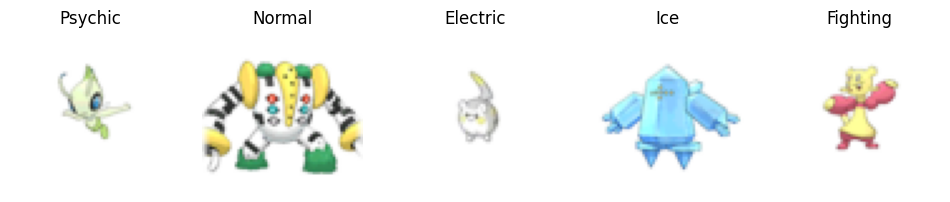

Epoch 5/30 | Train Loss: 2.6031 | Val Loss: 2.6579
Epoch 10/30 | Train Loss: 2.5052 | Val Loss: 2.5529
Epoch 15/30 | Train Loss: 2.4315 | Val Loss: 2.4888
Epoch 20/30 | Train Loss: 2.3789 | Val Loss: 2.4289
Epoch 25/30 | Train Loss: 2.3176 | Val Loss: 2.3960
Epoch 30/30 | Train Loss: 2.2631 | Val Loss: 2.3715


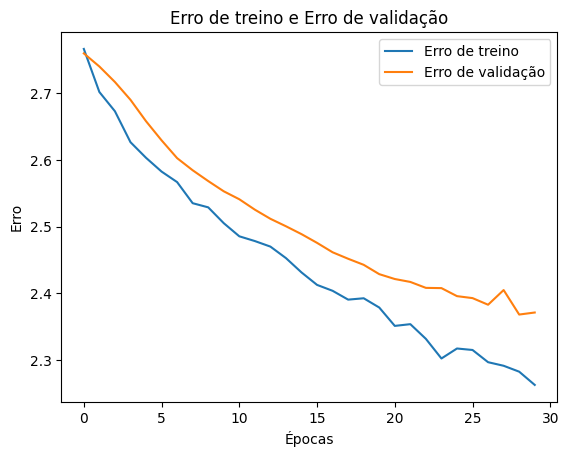


Acurácia final no teste: 30.25%


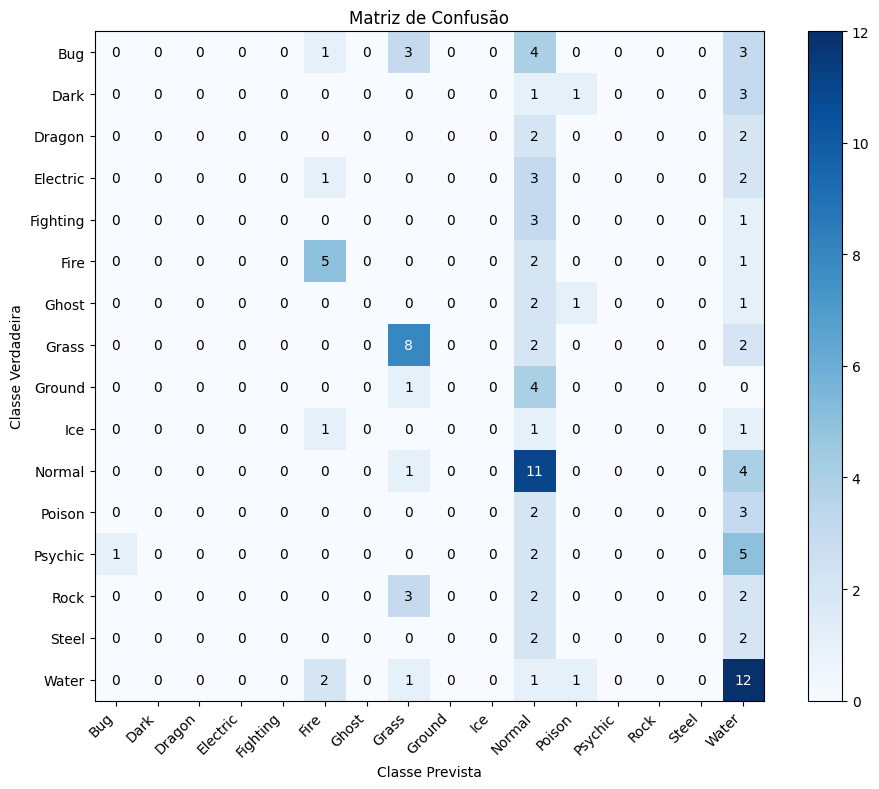

In [43]:
EPOCHS = 30
ETA = 1e-4
INPUT_SIZE = 3 * 64 * 64
FILTERS = [32, 64, 128]
OUTPUT_SIZE = 16
#L2 = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = [
    "Bug", "Dark", "Dragon", "Electric",
    "Fighting", "Fire", "Ghost", "Grass",
    "Ground", "Ice", "Normal", "Poison", 
    "Psychic", "Rock", "Steel", "Water"
]

# Carrega dados do Pokémon
train_loader, val_loader, test_loader = prepareData("db/pokemon.csv", "db/images/")
visualize_batch(train_loader, LABELS)
    
# --- 1. Instancia CNN ---
model = SimpleCNN(lista_filtros=FILTERS, num_classes=OUTPUT_SIZE).to(DEVICE)

# --- 2. Função de Erro correta para Multiclasse ---
loss_function = nn.CrossEntropyLoss() 

# --- 3. Otimizador ---
optimizer = optim.Adam(model.parameters(), lr=ETA)#, weight_decay=L2)

train_loss = {}
val_loss = {}

for i in range(EPOCHS):
    t_loss = trainModel(model, train_loader, loss_function, optimizer, DEVICE)
    v_loss = validateModel(model, val_loader, loss_function, DEVICE)
        
    train_loss[i] = t_loss
    val_loss[i] = v_loss
        
    if (i+1) % 5 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
# Plotagem dos erros
plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação")

# --- 4. Avaliação Final ---
acc, labels, predicted = testModel(model, test_loader, DEVICE)
print(f"\nAcurácia final no teste: {acc:.2f}%")

plotCMatrix(labels, predicted, LABELS, "assets/CNN_ConfusionMatrix2.png")

# Modelo 4 - CNN \[64, 128, 256\]
---

Verificamos um aumento pouco significativo da precisão do modelo, provavelmente decorrente do aumento do overfitting.

Uma possibilidade é utilizar o modelo anterior novamente, mas tentar controlar mais o erro de validação, garantindo que ele caia continuamente. Contudo, vamos continuar experimentando outras topologias antes de ajustar as que melhor se desempenharam no problema.

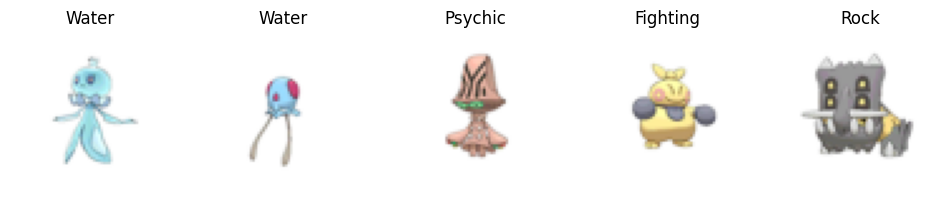

Epoch 5/30 | Train Loss: 2.5358 | Val Loss: 2.6107
Epoch 10/30 | Train Loss: 2.4146 | Val Loss: 2.4666
Epoch 15/30 | Train Loss: 2.3295 | Val Loss: 2.4058
Epoch 20/30 | Train Loss: 2.2638 | Val Loss: 2.3842
Epoch 25/30 | Train Loss: 2.1905 | Val Loss: 2.3494
Epoch 30/30 | Train Loss: 2.1694 | Val Loss: 2.3299


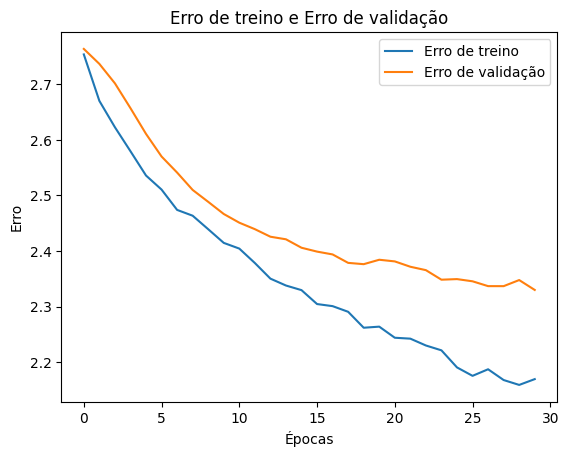


Acurácia final no teste: 31.93%


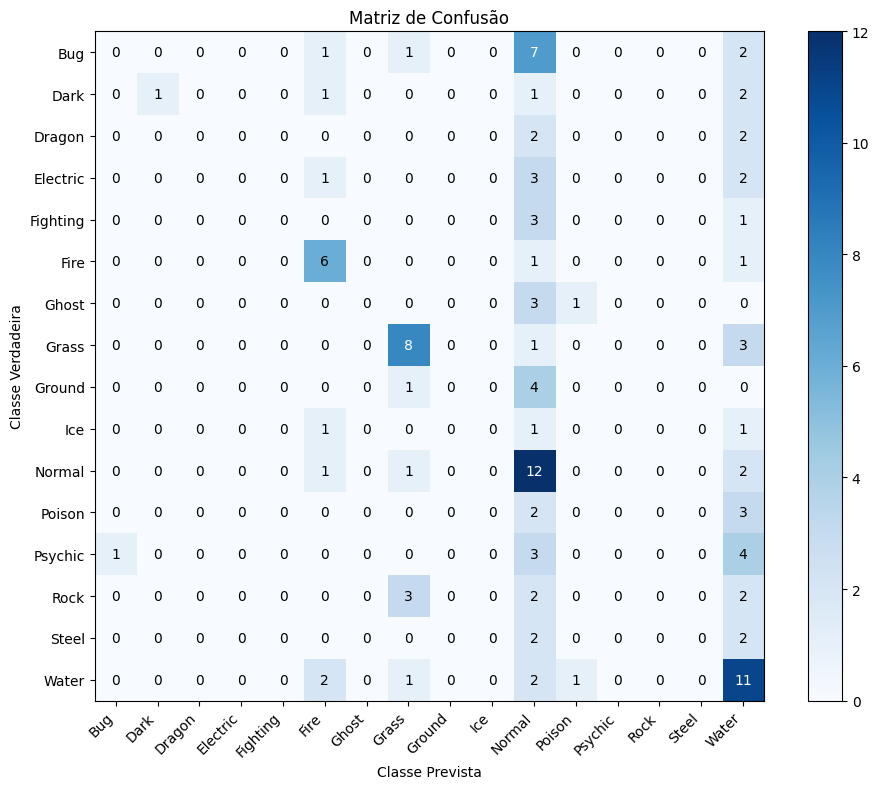

In [44]:
EPOCHS = 30
ETA = 1e-4
INPUT_SIZE = 3 * 64 * 64
FILTERS = [64, 128, 256]
OUTPUT_SIZE = 16
L2 = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = [
    "Bug", "Dark", "Dragon", "Electric",
    "Fighting", "Fire", "Ghost", "Grass",
    "Ground", "Ice", "Normal", "Poison", 
    "Psychic", "Rock", "Steel", "Water"
]

# Carrega dados do Pokémon
train_loader, val_loader, test_loader = prepareData("db/pokemon.csv", "db/images/")
visualize_batch(train_loader, LABELS)
    
# --- 1. Instancia CNN ---
model = SimpleCNN(lista_filtros=FILTERS, num_classes=OUTPUT_SIZE).to(DEVICE)

# --- 2. Função de Erro correta para Multiclasse ---
loss_function = nn.CrossEntropyLoss() 

# --- 3. Otimizador ---
optimizer = optim.Adam(model.parameters(), lr=ETA, weight_decay=L2)

train_loss = {}
val_loss = {}

for i in range(EPOCHS):
    t_loss = trainModel(model, train_loader, loss_function, optimizer, DEVICE)
    v_loss = validateModel(model, val_loader, loss_function, DEVICE)
        
    train_loss[i] = t_loss
    val_loss[i] = v_loss
        
    if (i+1) % 5 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
# Plotagem dos erros
plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação")

# --- 4. Avaliação Final ---
acc, labels, predicted = testModel(model, test_loader, DEVICE)
print(f"\nAcurácia final no teste: {acc:.2f}%")

plotCMatrix(labels, predicted, LABELS, "assets/CNN_ConfusionMatrix2.png")

# Modelo 5 - CNN \[64, 128, 64\]
---

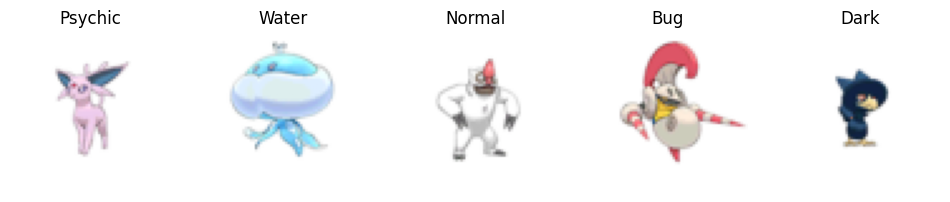

Epoch 5/30 | Train Loss: 2.6797 | Val Loss: 2.6963
Epoch 10/30 | Train Loss: 2.5978 | Val Loss: 2.6186
Epoch 15/30 | Train Loss: 2.5445 | Val Loss: 2.5694
Epoch 20/30 | Train Loss: 2.4788 | Val Loss: 2.5280
Epoch 25/30 | Train Loss: 2.4362 | Val Loss: 2.5096
Epoch 30/30 | Train Loss: 2.4054 | Val Loss: 2.4746


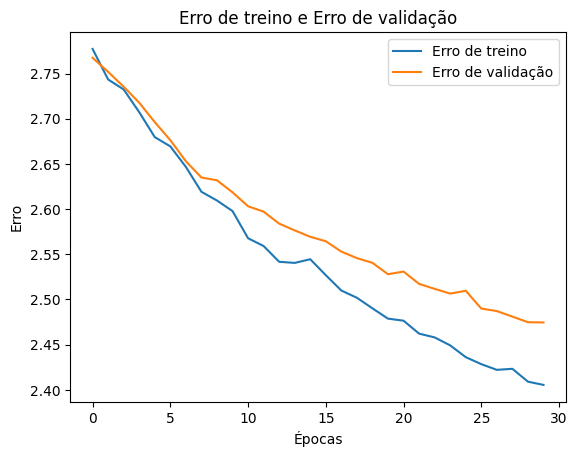


Acurácia final no teste: 30.25%


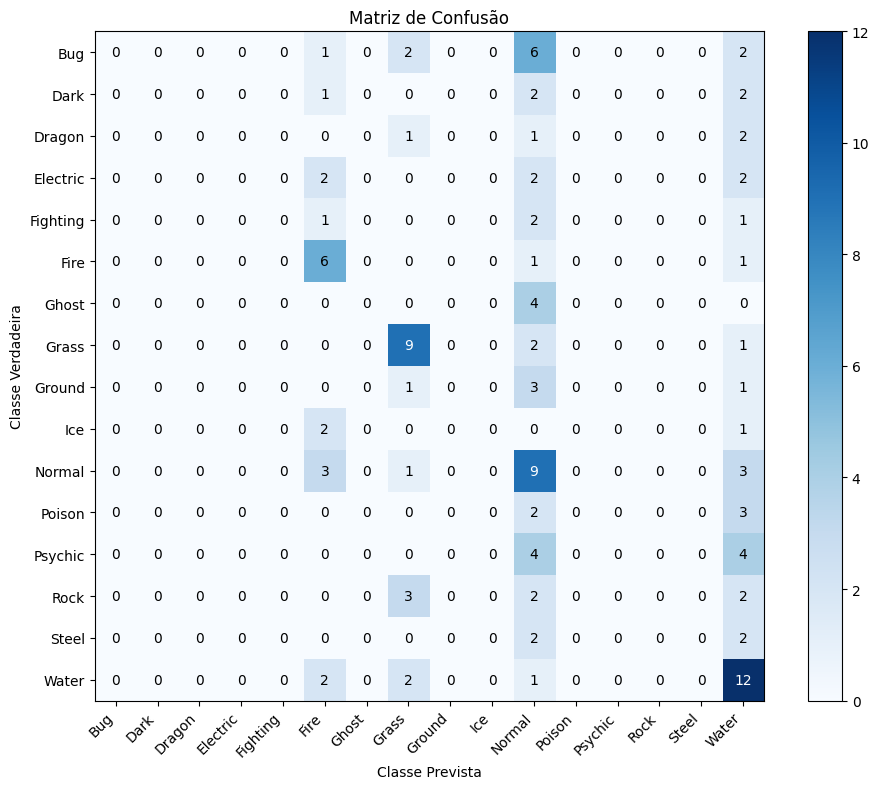

In [46]:
EPOCHS = 30
ETA = 1e-4
INPUT_SIZE = 3 * 64 * 64
FILTERS = [32, 64, 32]
OUTPUT_SIZE = 16
L2 = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = [
    "Bug", "Dark", "Dragon", "Electric",
    "Fighting", "Fire", "Ghost", "Grass",
    "Ground", "Ice", "Normal", "Poison", 
    "Psychic", "Rock", "Steel", "Water"
]

# Carrega dados do Pokémon
train_loader, val_loader, test_loader = prepareData("db/pokemon.csv", "db/images/")
visualize_batch(train_loader, LABELS)
    
# --- 1. Instancia CNN ---
model = SimpleCNN(lista_filtros=FILTERS, num_classes=OUTPUT_SIZE).to(DEVICE)

# --- 2. Função de Erro correta para Multiclasse ---
loss_function = nn.CrossEntropyLoss() 

# --- 3. Otimizador ---
optimizer = optim.Adam(model.parameters(), lr=ETA)#, weight_decay=L2)

train_loss = {}
val_loss = {}

for i in range(EPOCHS):
    t_loss = trainModel(model, train_loader, loss_function, optimizer, DEVICE)
    v_loss = validateModel(model, val_loader, loss_function, DEVICE)
        
    train_loss[i] = t_loss
    val_loss[i] = v_loss
        
    if (i+1) % 5 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
# Plotagem dos erros
plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação")

# --- 4. Avaliação Final ---
acc, labels, predicted = testModel(model, test_loader, DEVICE)
print(f"\nAcurácia final no teste: {acc:.2f}%")

plotCMatrix(labels, predicted, LABELS, "assets/CNN_ConfusionMatrix2.png")